In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [2]:
# Load NHANES data
df_NHANES = pd.read_csv('../data/NHANES.csv')

# Drop duplicate IDs
df_NHANES = df_NHANES.drop_duplicates(subset='ID')

In [3]:
### Table 3.1
table_df = df_NHANES['PhysActive'].value_counts(dropna=False).reset_index() # Index 'PhysActive' is meaningful
table_df.columns = ['PhysActive', 'AbsoluteFrequency']

# Sort rows
table_df = table_df.sort_values('PhysActive').reset_index(drop=True) # Index number not meaningful thus drop
table_df.style.hide(axis="index")

PhysActive,AbsoluteFrequency
No,2473
Yes,2972
nan,1334


In [4]:
### Table 3.2

# Remake table_df
table_df = df_NHANES['PhysActive'].value_counts().reset_index()
table_df.columns = ['PhysActive', 'AbsoluteFrequency']

# Add columns 'RelativeFrequency' and 'Percentage'
# Adjust round and cast
table_df['RelativeFrequency'] = (
    table_df['AbsoluteFrequency'] / table_df['AbsoluteFrequency'].sum()
)
table_df['Percentage'] = (table_df['RelativeFrequency'] * 100)

# Sort columns and rows
table_df = table_df.sort_values('PhysActive').reset_index(drop=True)
table_df = table_df[['PhysActive', 'AbsoluteFrequency', 'RelativeFrequency', 'Percentage']]

# Adjust format
table_df.style.format({'RelativeFrequency': '{:.2f}', 'Percentage':'{:.0f}'}).hide(axis="index")

PhysActive,AbsoluteFrequency,RelativeFrequency,Percentage
No,2473,0.45,45
Yes,2972,0.55,55


In [5]:
### Table 3.3
df_NHANES_sleep = df_NHANES.query('SleepHrsNight > 0')

table_df = df_NHANES_sleep['SleepHrsNight'].value_counts().reset_index()
table_df.columns = ['SleepHrsNight', 'AbsoluteFrequency']

table_df['RelativeFrequency'] = (
    table_df['AbsoluteFrequency'] / table_df['AbsoluteFrequency'].sum()
)
table_df['Percentage'] = (table_df['RelativeFrequency'] * 100)

table_df = table_df.sort_values('SleepHrsNight').reset_index(drop=True)
table_df = table_df[['SleepHrsNight', 'AbsoluteFrequency', 'RelativeFrequency', 'Percentage']]

table_df.style.format({'SleepHrsNight':'{:.0f}', 'RelativeFrequency': '{:.2f}', 'Percentage':'{:.2f}'}).hide(axis="index")

SleepHrsNight,AbsoluteFrequency,RelativeFrequency,Percentage
2,9,0.00,0.18
3,49,0.01,0.97
4,200,0.04,3.97
5,406,0.08,8.06
6,1172,0.23,23.28
7,1394,0.28,27.69
8,1405,0.28,27.90
9,271,0.05,5.38
10,97,0.02,1.93
11,15,0.00,0.30


<Axes: xlabel='SleepHrsNight', ylabel='Density'>

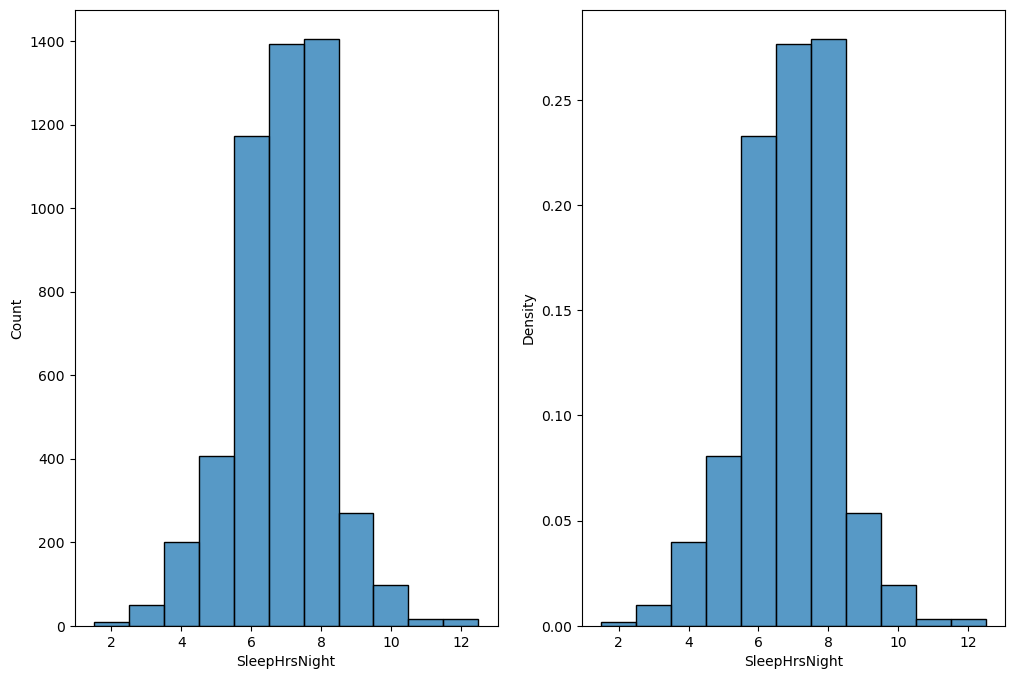

In [6]:
### Figure 3.2
fig, ax = plt.subplots(1, 2, figsize=(12,8))

sns.histplot(df_NHANES_sleep.SleepHrsNight, ax=ax[0], discrete=True)
sns.histplot(df_NHANES_sleep.SleepHrsNight, ax=ax[1], stat='density', discrete=True)

<Axes: xlabel='SleepHrsNight', ylabel='Density'>

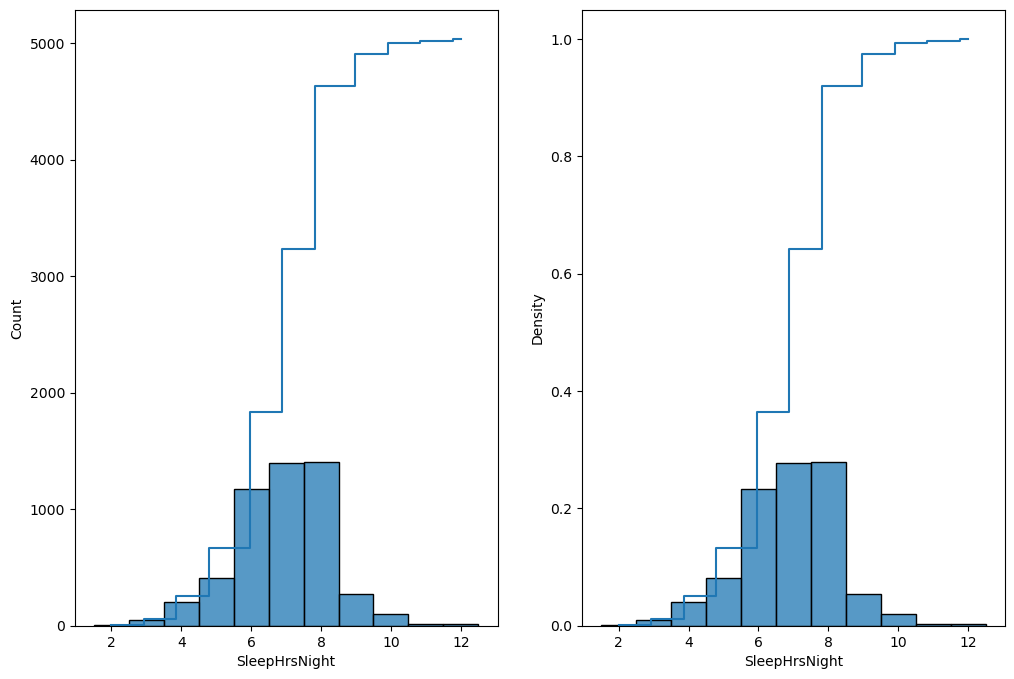

In [7]:
### Figure 3.3
fig, ax = plt.subplots(1, 2, figsize=(12,8))

sns.histplot(df_NHANES_sleep.SleepHrsNight, ax=ax[0],
             element="step", fill=False, cumulative=True)
sns.histplot(df_NHANES_sleep.SleepHrsNight,  ax=ax[0], discrete=True)

sns.histplot(df_NHANES_sleep.SleepHrsNight, ax=ax[1], stat='density',
             element="step", fill=False, cumulative=True)
sns.histplot(df_NHANES_sleep.SleepHrsNight, ax=ax[1], stat='density', discrete=True)

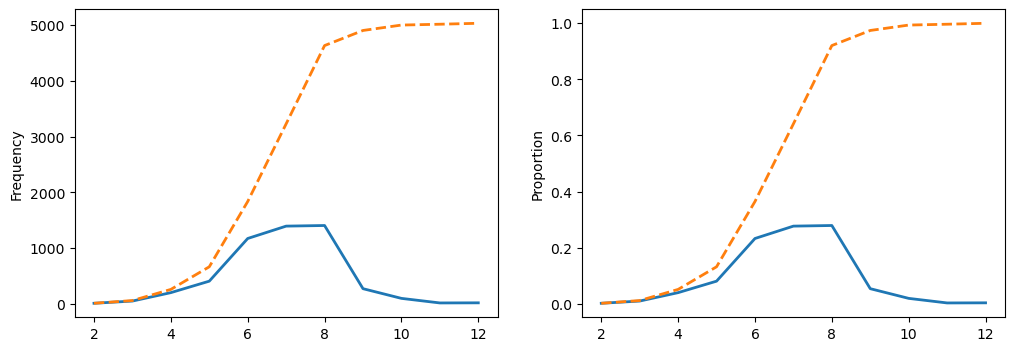

In [8]:
### Figure 3.3 Exact match
# --- Prepare the data (equivalent to the R dplyr pipeline) ---
SleepHrsNight_cumulative = (
    df_NHANES.dropna(subset=["SleepHrsNight"])
          .groupby("SleepHrsNight", as_index=False)
          .size()  # creates 'size' column
          .rename(columns={"size": "AbsoluteFrequency"})
)

SleepHrsNight_cumulative["RelativeFrequency"] = (
    SleepHrsNight_cumulative["AbsoluteFrequency"] /
    SleepHrsNight_cumulative["AbsoluteFrequency"].sum()
)

SleepHrsNight_cumulative["CumulativeDensity"] = \
    SleepHrsNight_cumulative["RelativeFrequency"].cumsum()

SleepHrsNight_cumulative["CumulativeFrequency"] = \
    SleepHrsNight_cumulative["AbsoluteFrequency"].cumsum()

# --- Plot p1 (absolute freq + cumulative freq) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
ax1.plot(
    SleepHrsNight_cumulative["SleepHrsNight"],
    SleepHrsNight_cumulative["AbsoluteFrequency"],
    linewidth=2
)
ax1.plot(
    SleepHrsNight_cumulative["SleepHrsNight"],
    SleepHrsNight_cumulative["CumulativeFrequency"],
    linestyle="--",
    linewidth=2
)
ax1.set_ylabel("Frequency")

# --- Plot p2 (relative freq + cumulative density) ---
ax2 = axes[1]
ax2.plot(
    SleepHrsNight_cumulative["SleepHrsNight"],
    SleepHrsNight_cumulative["RelativeFrequency"],
    linewidth=2
)
ax2.plot(
    SleepHrsNight_cumulative["SleepHrsNight"],
    SleepHrsNight_cumulative["CumulativeDensity"],
    linestyle="--",
    linewidth=2
)
ax2.set_ylabel("Proportion")

# plt.tight_layout()
plt.show()

In [9]:
SleepHrsNight_cumulative

,SleepHrsNight,AbsoluteFrequency,RelativeFrequency,CumulativeDensity,CumulativeFrequency
0,2.0,9,0.001787,0.001787,9
1,3.0,49,0.009732,0.011519,58
2,4.0,200,0.039722,0.051241,258
3,5.0,406,0.080636,0.131877,664
4,6.0,1172,0.232771,0.364647,1836
5,7.0,1394,0.276862,0.641509,3230
6,8.0,1405,0.279047,0.920556,4635
7,9.0,271,0.053823,0.974379,4906
8,10.0,97,0.019265,0.993644,5003
9,11.0,15,0.002979,0.996624,5018


<Axes: xlabel='Height', ylabel='Count'>

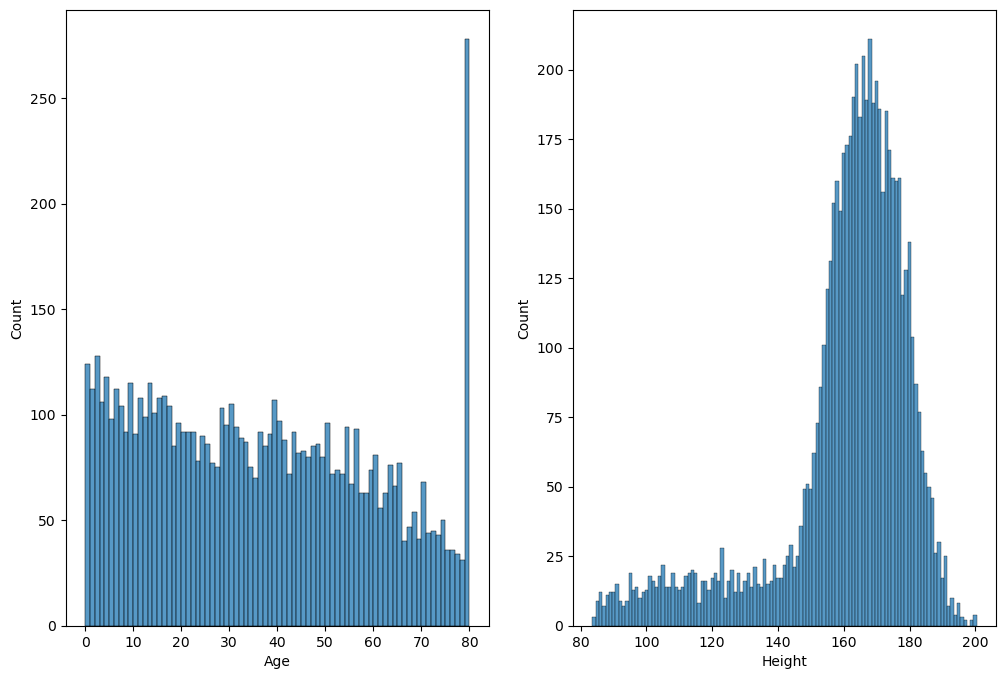

In [10]:
### Figure 3.4
fig, ax = plt.subplots(1, 2, figsize=(12,8))

sns.histplot(df_NHANES.Age, binwidth=1, ax=ax[0])

sns.histplot(df_NHANES.Height, binwidth=1, ax=ax[1])

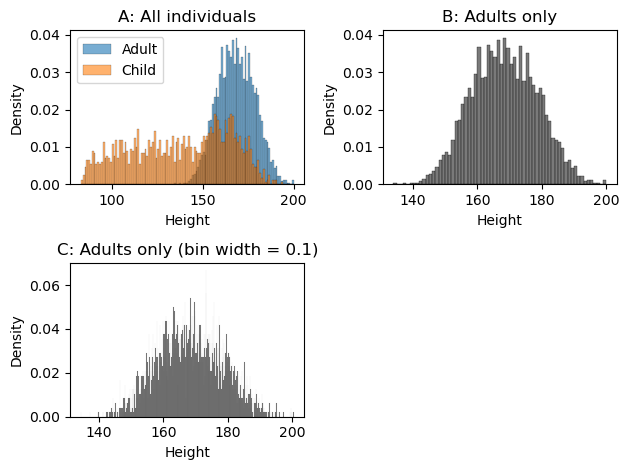

In [11]:
### Figure 3.5
df_NHANES_child = (
    df_NHANES.dropna(subset=["Age", "Height"]).query("Age < 18")
)
df_NHANES_adult = (
    df_NHANES.dropna(subset=["Age", "Height"]).query("Age >= 18")
)

# --- Plot p1 - All individuals, filled by isChild---

plt.subplot(2, 2, 1)
sns.histplot(
    data=df_NHANES_adult,
    x="Height",
    stat="density",
    label="Adult",
    bins=range(int(df_NHANES_child.Height.min()),
               int(df_NHANES_adult.Height.max()) + 1),
    alpha=0.6
)

sns.histplot(
    data=df_NHANES_child,
    x="Height",
    stat="density",
    label="Child",
    bins=range(int(df_NHANES_child.Height.min()),
               int(df_NHANES_adult.Height.max()) + 1),
    alpha=0.6
)

plt.legend(loc="upper left")
plt.title("A: All individuals")

# --- Plot p2 - Adults only, binwidth = 1 ---
plt.subplot(2, 2, 2)
sns.histplot(
    data=df_NHANES_adult,
    x="Height",
    bins=range(int(df_NHANES_adult.Height.min()), int(df_NHANES_adult.Height.max()) + 1),
    stat="density",
    color="0.3",
)
plt.title("B: Adults only")

# --- Plot p2 - Adults only, binwidth = 0.1 ---
plt.subplot(2, 2, 3)
sns.histplot(
    data=df_NHANES_adult.dropna(subset=["Height"]),
    x="Height",
    bins=int((df_NHANES_adult.Height.max() - df_NHANES_adult.Height.min()) / 0.1),
    stat="density",
    color="0.3",
)
plt.title("C: Adults only (bin width = 0.1)")

plt.tight_layout()
plt.show()


In [12]:
### Table 3.5
df_NHANES_adult["Height"][44:50]

95     169.6
96     169.8
100    167.5
101    155.2
103    173.8
106    174.5
Name: Height, dtype: float64

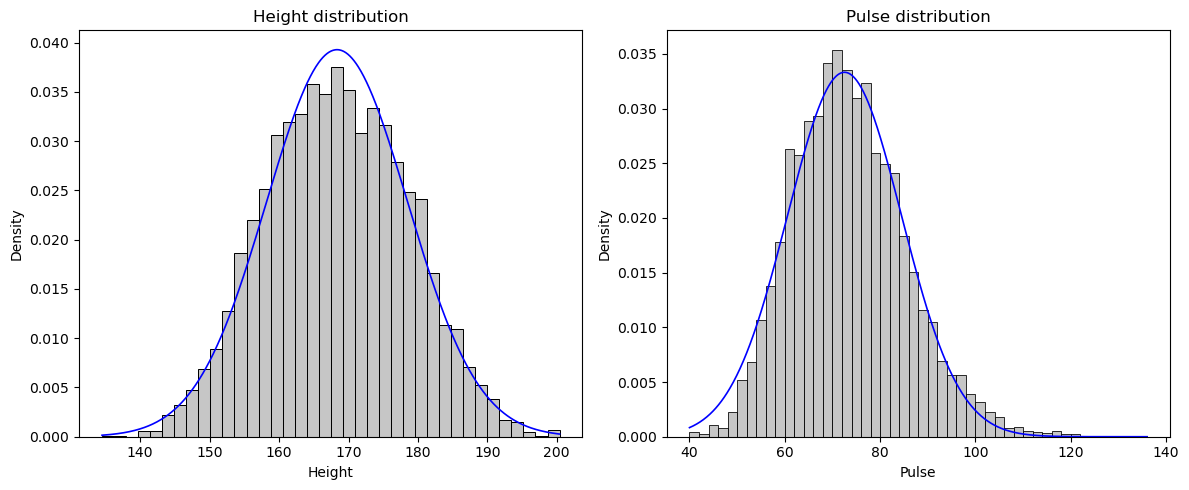

In [13]:
### Figure 4.6

# --- Compute summaries ---
def fd_bins(series):
    """Compute number of bins using Freedman–Diaconis rule,
       equivalent to nclass.FD() in R."""
    x = series.dropna()
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    n = x.size
    h = 2 * iqr / (n ** (1/3))
    if h == 0:
        return 1
    return int(np.ceil((x.max() - x.min()) / h))

# Pulse summary
pulse_series = df_NHANES_adult["Pulse"].dropna()

pulse_summary = {
    "nbins": fd_bins(pulse_series),
    "maxPulse": pulse_series.max(),
    "minPulse": pulse_series.min(),
    "meanPulse": pulse_series.mean(),
    "sdPulse": pulse_series.std()
}

# Height summary
height_series = df_NHANES_adult["Height"].dropna()

height_summary = {
    "nbins": fd_bins(height_series),
    "maxHeight": height_series.max(),
    "minHeight": height_series.min(),
    "meanHeight": height_series.mean(),
    "sdHeight": height_series.std()
}

height_summary["binwidth"] = (
    (height_summary["maxHeight"] - height_summary["minHeight"]) /
    height_summary["nbins"]
)

# --- Create normal distribution curves ---
heightDist = pd.DataFrame({
    "x": np.arange(height_summary["minHeight"],
                   height_summary["maxHeight"] + 0.1, 0.1)
})
heightDist["y"] = norm.pdf(
    heightDist["x"],
    loc=height_summary["meanHeight"],
    scale=height_summary["sdHeight"]
)

pulseDist = pd.DataFrame({
    "x": np.arange(pulse_summary["minPulse"],
                   pulse_summary["maxPulse"] + 0.1, 0.1)
})
pulseDist["y"] = norm.pdf(
    pulseDist["x"],
    loc=pulse_summary["meanPulse"],
    scale=pulse_summary["sdPulse"]
)

# --- Plot histograms with normal curves on top ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Height histogram 
sns.histplot(
    df_NHANES_adult["Height"].dropna(),
    stat="density",
    binwidth=height_summary["binwidth"],
    ax=axes[0],
    color="0.7"
)
axes[0].plot(heightDist["x"], heightDist["y"], color="blue", linewidth=1.2)
axes[0].set_title("Height distribution")

# Pulse histogram
sns.histplot(
    df_NHANES_adult["Pulse"].dropna(),
    stat="density",
    binwidth=2,
    ax=axes[1],
    color="0.7"
)
axes[1].plot(pulseDist["x"], pulseDist["y"], color="blue", linewidth=1.2)
axes[1].set_title("Pulse distribution")

plt.tight_layout()
plt.show()

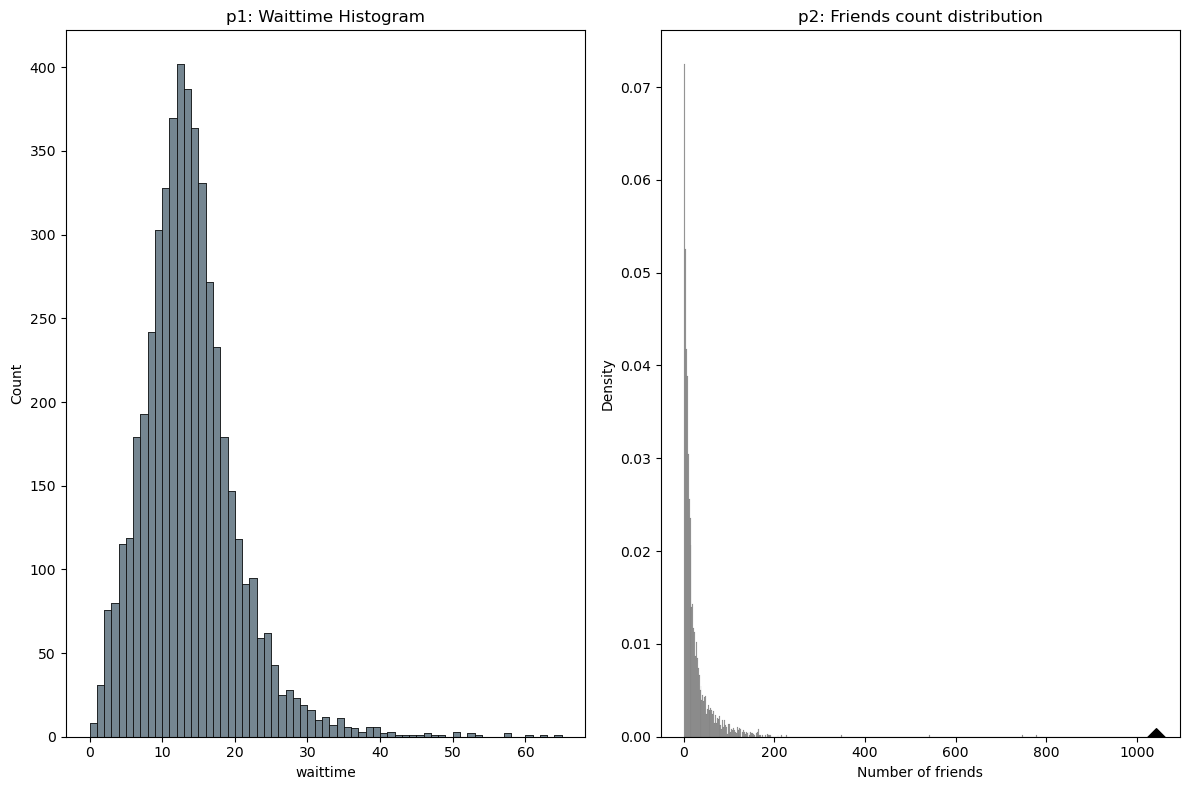

In [14]:
### Figure 3.7
waittimes = pd.read_csv('https://raw.githubusercontent.com/statsthinking21/statsthinking21-figures-data/main/04/sfo_wait_times_2017.csv')

fig, ax = plt.subplots(1, 2, figsize=(12,8))
sns.histplot(waittimes.waittime, binwidth=1, ax=ax[0])

fbdata = pd.read_csv('https://raw.githubusercontent.com/statsthinking21/statsthinking21-figures-data/main/04/facebook_combined.txt', names=['V1', 'V2'], delimiter=' ')

# --- Histogram of waittime (binwidth = 1) ---
sns.histplot(
    data=waittimes,
    x="waittime",
    binwidth=1,               # matches geom_histogram(binwidth=1)
    color="0.5",
    ax=ax[0]
)
ax[0].set_xlabel("waittime")
ax[0].set_ylabel("Count")
ax[0].set_title("p1: Waittime Histogram")

# --- Count how many friends each individual has ---
friends_table = (
    fbdata
    .groupby("V1")
    .size()
    .reset_index(name="nfriends")
)

# --- Histogram + density + annotation ---
sns.histplot(
    data=friends_table,
    x="nfriends",
    stat="density",          
    binwidth=2,
    color="0.5",
    ax=ax[1]
)

ax[1].set_xlabel("Number of friends")
ax[1].set_title("p2: Friends count distribution")

# Annotate a point at (max friends, 0)
ax[1].scatter(
    friends_table["nfriends"].max(),
    0,
    s=80,                    # roughly matches ggplot size=4
    marker="D",              # diamond, similar to shape=18
    color="black"
)

plt.tight_layout()
plt.show()